<a href="https://colab.research.google.com/github/ruforavishnu/Project_Simulations/blob/main/12th_Standard_Maths_Chapter7_Integrals_Section1_Definite_Integrals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 7 - Integrals


## Definite Integrals

**Problem**

A Sintex water tank has a diameter of 135 cm and a height of 126.5 cm. We know that water enters through a pipe of 1 inch diameter at a flow speed of 2 m/s.
Find out how much water will be filled in the tank if the motor switch is kept turned on for 10 mins, 15mins and 20 mins each.







In [3]:
import math
import pandas as pd



In [5]:
diameter_tank = 1.35
height_tank = 1.265

radius_tank = diameter_tank / 2

In [9]:
diameter_pipe = 0.0254 # 1 inch
radius_pipe = diameter_pipe/2

flow_speed = 2

tank_capacity = math.pi * radius_tank**2 * height_tank


flow_rate = math.pi * radius_pipe**2 *flow_speed



In [10]:
times = [10, 15, 20] #time in minutes. putting it in an array

results = []


for t in times:
  t_seconds = t * 60
  volume_filled = flow_rate * t_seconds
  height_filled = volume_filled / (math.pi * radius_tank**2)
  percent_full = (volume_filled / tank_capacity) * 100

  results.append({
      'minutes': t,
      'volume (litres)': volume_filled * 1000,
      'height (m)' : height_filled,
      'percent_full': percent_full

  })




In [12]:
df = pd.DataFrame(results)

print(f'Tank Capacity: {tank_capacity:.3f} m³ ({tank_capacity*1000:.1f} litres)')
print(f'Pipe flow rate: {flow_rate:.6f} m³/s ({flow_rate*1000:.3f} L/s)')
print('\n\n')
df

Tank Capacity: 1.811 m³ (1810.7 litres)
Pipe flow rate: 0.001013 m³/s (1.013 L/s)





,minutes,volume (litres),height (m),percent_full
0,10,608.048975,0.424797,33.580767
1,15,912.073462,0.637195,50.371151
2,20,1216.097950,0.849593,67.161535


**fine. now lets plot it**

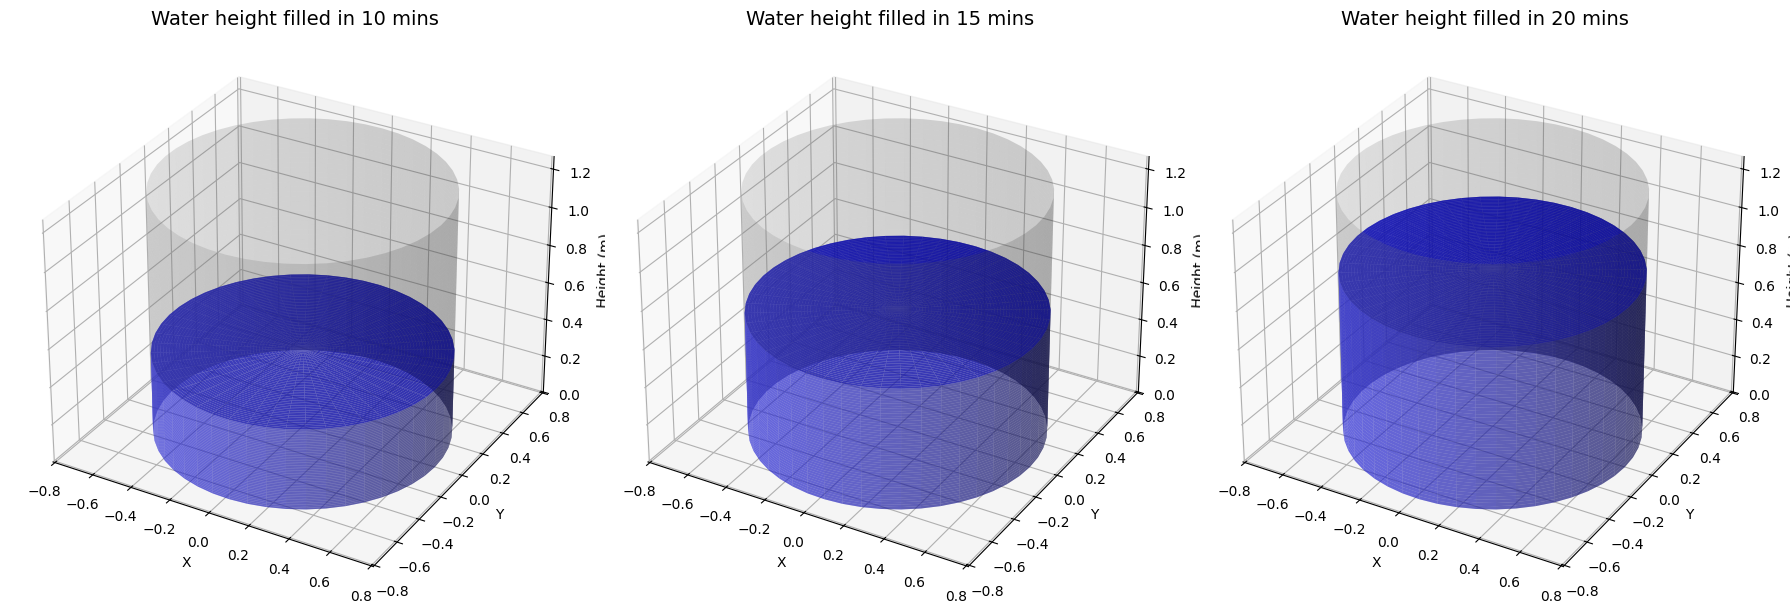

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_cylinder(ax,  radius,  height ,  color , alpha=0.5):
  z = np.linspace(0, height, 50)
  theta = np.linspace(0,  2*np.pi,   50)
  theta_grid, z_grid = np.meshgrid(theta, z)

  x_grid = radius * np.cos(theta_grid)
  y_grid = radius * np.sin(theta_grid)

  ax.plot_surface(x_grid, y_grid,   z_grid,   color=color,   alpha=alpha,  linewidth=0)


def plot_disk(ax, radius, z,  color, alpha=0.6):
  theta = np.linspace(0,   2*np.pi, 50)
  r = np.linspace(0,  radius,  50)
  R, Theta = np.meshgrid(r,  theta)

  X = R * np.cos(Theta)
  Y = R * np.sin(Theta)
  Z = np.full_like(X, z)

  ax.plot_surface(X,  Y,  Z,  color=color,  alpha=alpha,  linewidth=0)



fig = plt.figure(figsize=(18,6))

for i, row in enumerate(results, start = 1):
  ax = fig.add_subplot(1,  3,  i,  projection='3d')
  plot_cylinder(ax, radius_tank, height_tank,  color='gray', alpha=0.2)
  water_height = min(row['height (m)'],  height_tank)
  plot_cylinder(ax,  radius_tank, water_height, color='blue', alpha=0.6)

  if water_height > 0:
    plot_disk(ax, radius_tank,  water_height,   color='blue', alpha=0.8)

  ax.set_title(f'Water height filled in {row['minutes']} mins', fontsize=14)
  ax.set_xlim([-radius_tank*1.2, radius_tank*1.2])
  ax.set_ylim([-radius_tank*1.2, radius_tank*1.2])
  ax.set_zlim([0, height_tank])
  ax.set_xlabel('X')
  ax.set_ylabel('Y')
  ax.set_zlabel('Height (m)')

plt.tight_layout()
plt.show()




**fine. thats done**